# MOSFET Python Solver Test
Run the solver with default values and print compact output summaries.

In [ ]:
import numpy as np
import importlib
from pathlib import Path

try:
    from Features.Electronics_Application.MosfetEvaluator.pdd_solver_python import MosfetSolver as _ms
except Exception:
    import MosfetSolver as _ms

_ms = importlib.reload(_ms)
print('Using MosfetSolver from:', Path(_ms.__file__).resolve())

results = _ms.run()

print('Keys:', list(results.keys()))
print('J shape:', results['J'].shape)
print('Q shape:', results['Q'].shape)
print('Vgs shape:', results['Vgs'].shape, 'range:', (results['Vgs'].min(), results['Vgs'].max()))
print('Vds shape:', results['Vds'].shape, 'range:', (results['Vds'].min(), results['Vds'].max()))
print('x shape:', results['x'].shape)
print('y shape:', results['y'].shape)

print('J min/max:', (results['J'].min(), results['J'].max()))
print('Q min/max:', (results['Q'].min(), results['Q'].max()))

print('Vgs:', np.array2string(results['Vgs'], precision=4))
print('Vds:', np.array2string(results['Vds'], precision=4))
print('J[0:3, 0:3]:\n', results['J'][0:3, 0:3])
print('Q[0:3, 0:3]:\n', results['Q'][0:3, 0:3])



## Id/W - Vd
MOSFET output characteristic: drain current per width versus drain voltage at fixed gate biases. 9 representative Vgs lines from the available sweep.

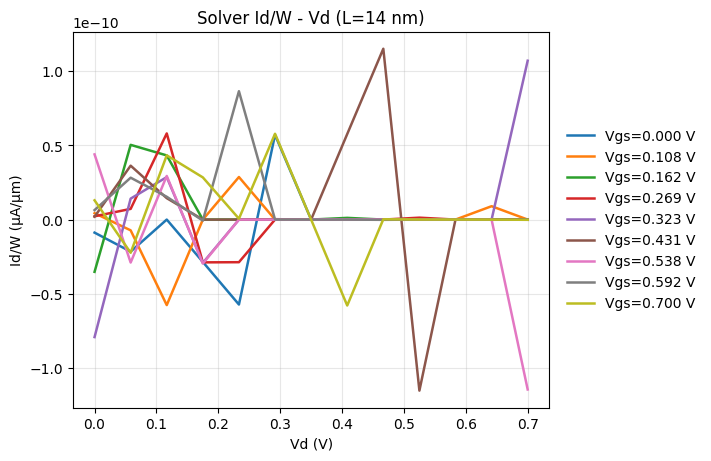

Plotted solver curves: 9 Vgs lines: [0.     0.1077 0.1615 0.2692 0.3231 0.4308 0.5385 0.5923 0.7   ]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

Vgs = np.asarray(results['Vgs'])
Vds = np.asarray(results['Vds'])
J = np.asarray(results['J'])  # shape: (Nvg, Nvd)

# 1 A/m == 1 μA/μm numerically, so we can relabel directly.
IdW_uA_per_um = J

# Select 9 representative gate-bias curves across the available Vgs range.
target_vgs = np.linspace(Vgs.min(), Vgs.max(), 9)
sel_idx = [int(np.argmin(np.abs(Vgs - v))) for v in target_vgs]
sel_idx = list(dict.fromkeys(sel_idx))

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

for i in sel_idx:
    ax.plot(Vds, IdW_uA_per_um[i, :], lw=1.8, label=f"Vgs={Vgs[i]:.3f} V")

ax.set_title("Solver Id/W - Vd (L=14 nm)")
ax.set_xlabel("Vd (V)")
ax.set_ylabel("Id/W (μA/μm)")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.show()

print("Plotted solver curves:", len(sel_idx), "Vgs lines:", np.round(Vgs[sel_idx], 4))

## Reference Id/W - Vd (MATLAB Solver)
Plot from the provided CSV reference data generated from the MATLAB solver, using the same units as the solver plot: Id/W in μA/μm.

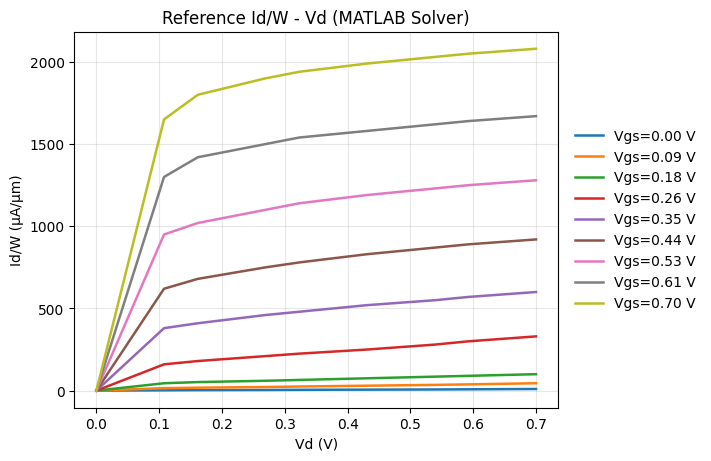

Plotted MATLAB reference curves: 9 Vgs lines


In [15]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("mosfet_refernce_plot.csv")

with csv_path.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    # Strip zero-width spaces in headers.
    fieldnames = [name.replace("\u200b", "").strip() for name in reader.fieldnames]

    rows = []
    for raw_row in reader:
        row = {}
        for k, v in raw_row.items():
            clean_k = k.replace("\u200b", "").strip()
            row[clean_k] = float(v)
        rows.append(row)

vd_col = "Vd (V)"
vgs_cols = [c for c in fieldnames if c.startswith("Vgs=")]

Vd_ref = np.array([r[vd_col] for r in rows], dtype=float)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

for col in vgs_cols:
    vgs_val = float(col.split("=")[1])
    IdW_ref = np.array([r[col] for r in rows], dtype=float)  # already in μA/μm
    ax.plot(Vd_ref, IdW_ref, lw=1.8, label=f"Vgs={vgs_val:.2f} V")

ax.set_title("Reference Id/W - Vd (MATLAB Solver)")
ax.set_xlabel("Vd (V)")
ax.set_ylabel("Id/W (μA/μm)")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.show()

print("Plotted MATLAB reference curves:", len(vgs_cols), "Vgs lines")

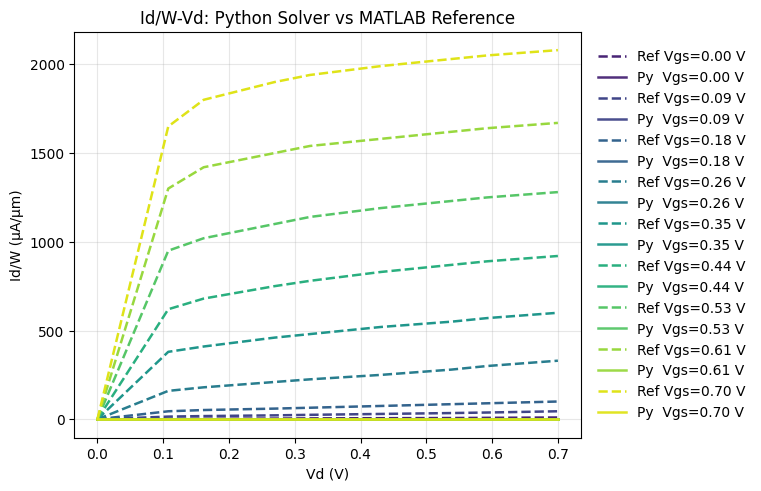

Comparison metrics on reference grid -> MAE: 616.790 μA/μm, MAPE: 88.89%
Python @ Vgs=0.70V: [ 0.  0.  0.  0.  0. -0.  0.  0. -0.]
Ref    @ Vgs=0.70V: [   0. 1650. 1800. 1900. 1940. 1990. 2030. 2050. 2080.]


In [16]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Re-load reference CSV in a robust way (strip zero-width spaces in headers)
csv_path = Path("mosfet_refernce_plot.csv")
with csv_path.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    fieldnames = [name.replace("\u200b", "").strip() for name in reader.fieldnames]
    rows = []
    for raw_row in reader:
        row = {}
        for k, v in raw_row.items():
            clean_k = k.replace("\u200b", "").strip()
            row[clean_k] = float(v)
        rows.append(row)

vd_col = "Vd (V)"
vgs_cols = [c for c in fieldnames if c.startswith("Vgs=")]
Vd_ref = np.array([r[vd_col] for r in rows], dtype=float)
Vgs_ref = np.array([float(c.split("=")[1]) for c in vgs_cols], dtype=float)
Id_ref = np.array([[r[c] for c in vgs_cols] for r in rows], dtype=float).T  # (Nvgs_ref, Nvd_ref)

Vgs = np.asarray(results['Vgs'])
Vds = np.asarray(results['Vds'])
J = np.asarray(results['J'])

# Interpolate solver data onto (Vgs_ref, Vd_ref) grid for apples-to-apples comparison
Id_solver_on_ref = np.zeros_like(Id_ref)
for i, vgs_target in enumerate(Vgs_ref):
    j_vs_vds = np.array([np.interp(vgs_target, Vgs, J[:, k]) for k in range(len(Vds))])
    Id_solver_on_ref[i, :] = np.interp(Vd_ref, Vds, j_vs_vds)

mae = np.mean(np.abs(Id_solver_on_ref - Id_ref))
mape = np.mean(np.abs((Id_solver_on_ref - Id_ref) / np.maximum(1.0, np.abs(Id_ref)))) * 100.0

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.95, len(Vgs_ref)))

for i, (vgs_val, c) in enumerate(zip(Vgs_ref, colors)):
    ax.plot(Vd_ref, Id_ref[i, :], '--', color=c, lw=1.8, label=f"Ref Vgs={vgs_val:.2f} V")
    ax.plot(Vd_ref, Id_solver_on_ref[i, :], '-', color=c, lw=1.8, alpha=0.95, label=f"Py  Vgs={vgs_val:.2f} V")

ax.set_title("Id/W-Vd: Python Solver vs MATLAB Reference")
ax.set_xlabel("Vd (V)")
ax.set_ylabel("Id/W (μA/μm)")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1)
plt.show()

print(f"Comparison metrics on reference grid -> MAE: {mae:.3f} μA/μm, MAPE: {mape:.2f}%")
print("Python @ Vgs=0.70V:", np.round(Id_solver_on_ref[-1], 2))
print("Ref    @ Vgs=0.70V:", np.round(Id_ref[-1], 2))

